In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import os 
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# PLSSVD: fixed-dimension generalization to held-out trials
5 random 70/30 train/test splits. Every split uses all available participants, with the same participant assignment and random-control source sampling throughout. Only trial partitions change.
Evaluates new trials from the same participants.

```bash
python -u plssvd_eval.py --root /path/to/iEEGvsMEG \
  --meg-kind full_concatenated --n-components 5 --repeats 5 \
  --train-fraction 0.7 --output-dir /path/to/plssvd_eval
```

In [9]:
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
sys.path.insert(0, str(ROOT.parent / 'LB'))
from plssvd_eval_utils import (ValidationOptions, 
                               prepare_trial_cache, load_trial_cache,
                               validate_plssvd, plot_plssvd_validation, 
                               load_plssvd_results,)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

In [10]:
MEG_KIND = 'full_concatenated'
# Illustrative batch defaults; this notebook loads results rather than running the analysis.
options = ValidationOptions(
    n_components=5, repeats=5, train_fraction=0.7,
    n_null=199, seed=2026, split_unit='trial', block_scaling='none',
)
CACHE_DIR = ROOT / 'out' / 'trial_cache'
OUTPUT_DIR = ROOT / 'out' / f'plssvd_eval_{MEG_KIND}'


## Load unaveraged trials
Metadata CSV columns:
| Column | Meaning |
|---|---|
| modality | `ieeg` or `meg` |
| subject | Filename participant identifier |
| condition | Original condition code, e.g. 1 or 2 |
| trial_index | Zero-based trial index **within that condition** |
| split_group | Run or repeated stimulus identity; with `split_unit='group'`, never crosses partitions |
| permutation_block | Acoustic or other exchangeability stratum for condition-label shuffling |

Each condition needs at least six trials: at least two for training and two in each test half. 
The 70/30 fraction is adjusted for small counts. 

Group splitting requires at least three distinct groups and sufficient observations in both conditions; the fraction applies approximately to group counts. A cache made with different metadata/configuration must be rebuilt in a new directory.


In [11]:
result = load_plssvd_results(OUTPUT_DIR)
if result['validation_options'].get('schema_version', 1) < 2:
    raise ValueError('These are legacy tuning-based results. Run the updated batch script with fixed --n-components into a new directory.')
MEG_KIND = result['validation_options']['meg_kind']
print(f"Loaded {MEG_KIND}: {result['validation_options']['repeats']} random train/test splits, "
      f"fixed k={result['validation_options']['n_components']}")
display(pd.Series(result['validation_options'], name='Saved evaluation settings'))
display(result['trial_counts'] if not result['trial_counts'].empty else result['participants'])


Loaded full_concatenated: 5 random train/test splits, fixed k=5


repeats                                                               5
n_components                                                          5
train_fraction                                                      0.7
n_null                                                              199
seed                                                               2026
split_unit                                                        trial
block_scaling                                                      none
ridge                                                             0.001
max_gram_gib                                                        2.0
schema_version                                                        2
meg_kind                                              full_concatenated
design                fixed-k repeated random train/test holdout; no...
partitions                                [train, test_a, test_b, test]
ieeg_preprocessing                                fixed multipli

,modality,subject,condition,n_trials,n_channels,n_times
0,ieeg,BJH026,1,24,70,1025
1,ieeg,BJH026,2,24,70,1025
2,ieeg,BJH027,1,24,137,1025
3,ieeg,BJH027,2,24,137,1025
4,ieeg,BJH029,1,24,133,1025
...,...,...,...,...,...,...
117,meg,SUBJ_0036,2,23,3559,1025
118,meg,SUBJ_0037,1,20,3559,1025
119,meg,SUBJ_0037,2,25,3559,1025
120,meg,SUBJ_0039,1,24,3559,1025


## Train once per split, then test — no tuning
Trials are randomly assigned within each participant, modality and condition to approximately 70% training and 30% testing. \
Each split starts from the same cached cohort and identical anatomical/participant assignment. Later splits refit preprocessing and all model parameters on a fresh random training set. Predictions concern condition-averaged signals.

In [13]:
display(result['summary'].round(3))
display(result['metric_summary'].query("partition == 'test'").round(3))

,repeat,n_components,n_ieeg,n_meg,n_meg_contributing,train_mean_r,test_mean_r,test_mean_abs_contrast_r,predict_ieeg_q2,predict_meg_q2,...,test_crosscov_energy_fraction,test_paired_crosscov_energy_fraction,test_mean_paired_covariance,test_total_crosscov_energy,test_captured_crosscov_energy,ieeg_split_half_r,meg_split_half_r,ieeg_pattern_split_half_r,meg_pattern_split_half_r,paired_covariance_retention
0,0,5,30,31,31,0.900,0.615,0.241,0.091,0.035,...,0.098,0.095,133.309,1955235.654,191872.953,0.837,0.601,0.328,0.405,0.454
1,1,5,30,31,31,0.895,0.592,0.173,0.063,0.031,...,0.093,0.088,122.493,1864944.888,173298.046,0.834,0.566,0.322,0.401,0.412
2,2,5,30,31,31,0.898,0.627,0.313,0.068,0.029,...,0.083,0.080,116.937,1833445.200,151898.656,0.801,0.546,0.302,0.419,0.380
3,3,5,30,31,31,0.893,0.622,0.234,0.072,0.026,...,0.095,0.086,123.483,2000706.908,189522.016,0.873,0.575,0.256,0.413,0.419
4,4,5,30,31,31,0.894,0.619,0.344,0.089,0.034,...,0.087,0.083,127.802,2049179.102,178657.992,0.875,0.648,0.305,0.415,0.430


,partition,metric,count,mean,std,median,min,max
1,test,ieeg_reconstruction_fraction,5,0.127,0.005,0.130,0.122,0.131
3,test,predict_ieeg_q2,5,0.077,0.012,0.072,0.063,0.091
5,test,meg_reconstruction_fraction,5,0.052,0.001,0.052,0.051,0.054
7,test,predict_meg_q2,5,0.031,0.004,0.031,0.026,0.035
9,test,crosscov_energy_fraction,5,0.091,0.006,0.093,0.083,0.098
11,test,paired_crosscov_energy_fraction,5,0.086,0.005,0.086,0.080,0.095
13,test,mean_paired_covariance,5,124.805,6.130,123.483,116.937,133.309
15,test,total_crosscov_energy,5,1940702.350,90584.572,1955235.654,1833445.200,2049179.102
17,test,captured_crosscov_energy,5,177049.933,16004.093,178657.992,151898.656,191872.953
19,test,mean_r,5,0.615,0.014,0.619,0.592,0.627


## Goodness on held-out data: signal fit and shared covariance

**1. Own-modality reconstruction.** For each modality, project the test signals onto the training-learned PLS weight space and reconstruct them using the same weights:
Any training whole-modality scale is undone for reconstruction. `ieeg_reconstruction_fraction` and `meg_reconstruction_fraction` report how much of each test signal the learned space retains.

**2. Cross-modal prediction.** Training ridge regressions map MEG scores to iEEG features and iEEG scores to MEG features. `predict_ieeg_q2` and `predict_meg_q2` are `1 − test squared error / training-mean-baseline squared error`. Positive Q² improves on that baseline; negative Q² is worse.

**3. Held-out cross-covariance.** Let C be the full test-feature cross-covariance after partition centering and the training-learned scaling, and let Wx/Wy be the training PLS weights. The test score covariance matrix is `Wx.T @ C @ Wy`. `crosscov_energy_fraction` is its squared Frobenius norm divided by `||C||F²`.This is the fraction of observed test cross-covariance energy retained by the trained spaces.

Also report `mean_paired_covariance` (signed diagonal mean in native score units), per-component train/test covariance, `paired_crosscov_energy_fraction` (diagonal energy only), and signed paired score Pearson r. A covariance fraction can be high even when the absolute shared signal is weak, so inspect these measures together. Covariance retention relative to training is in `summary.csv` and can exceed one or become negative.

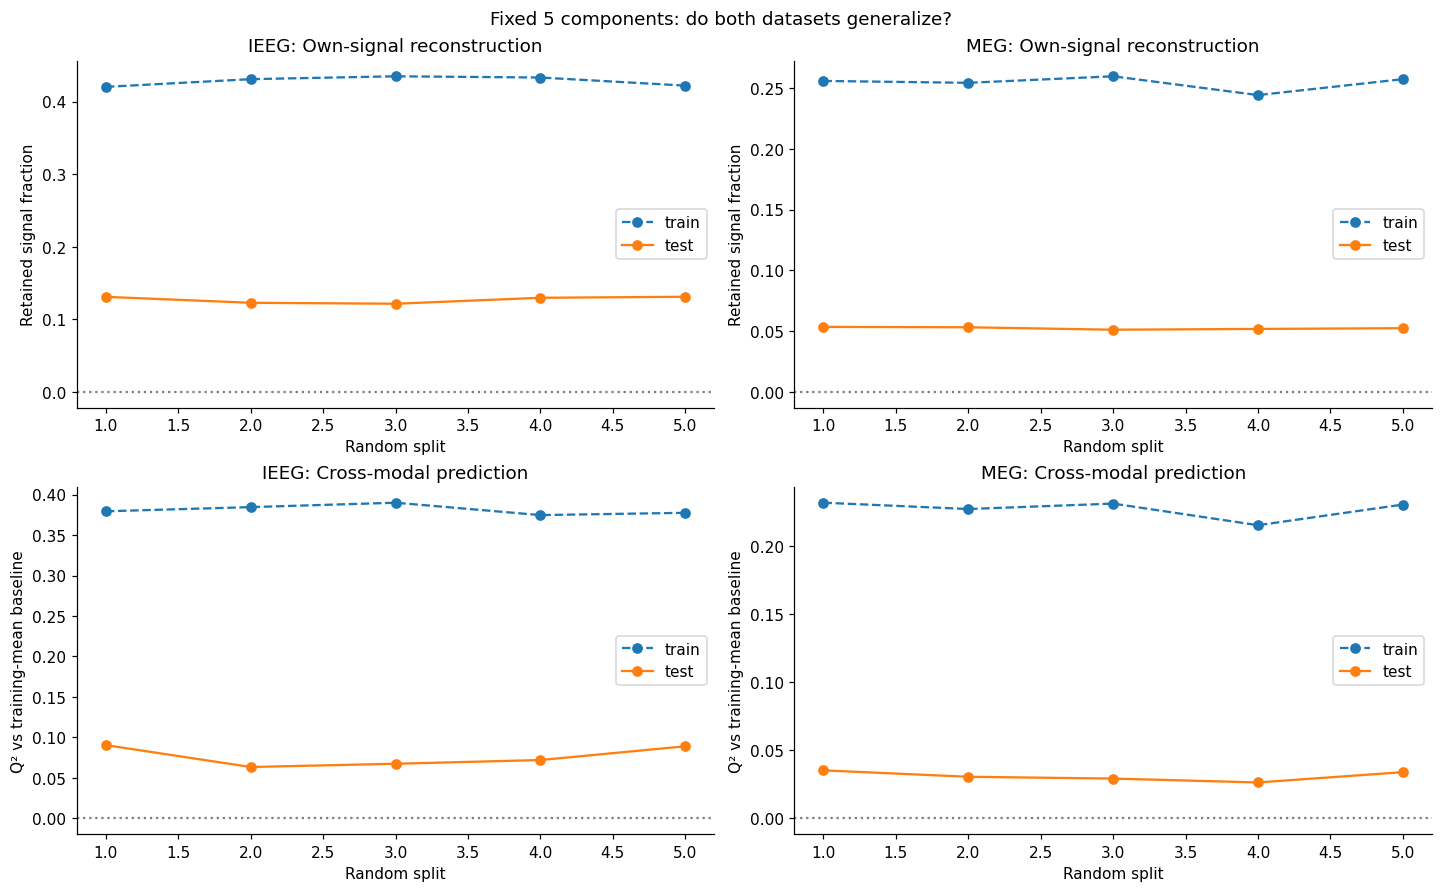

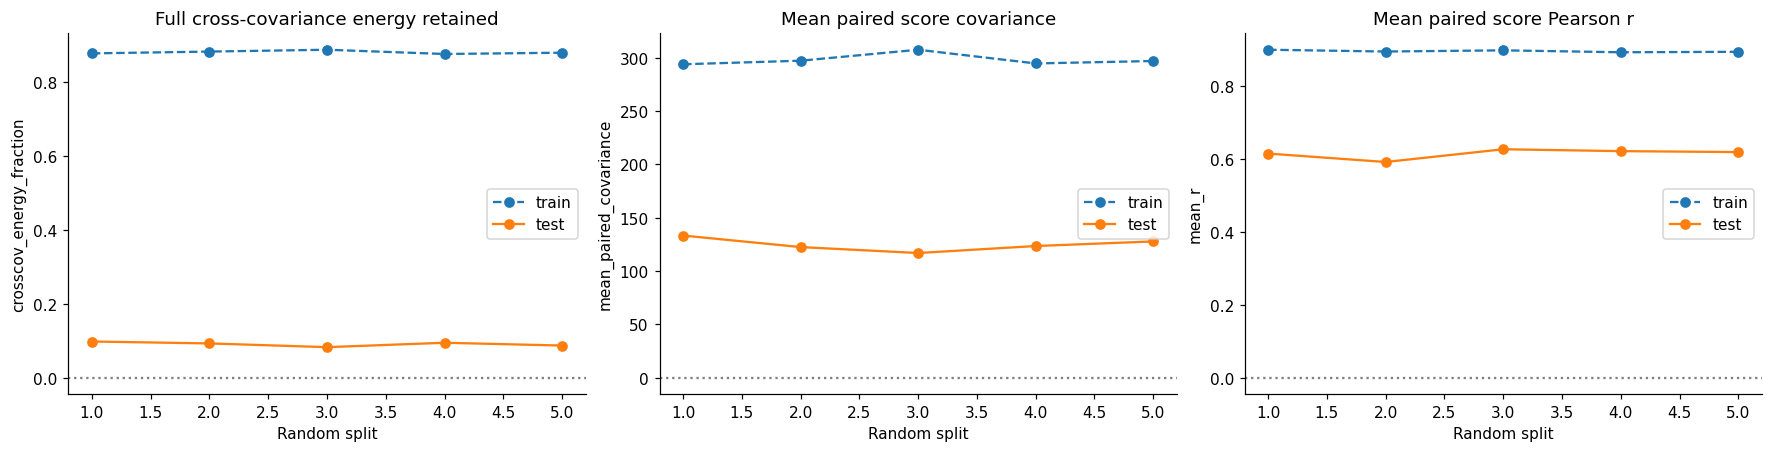

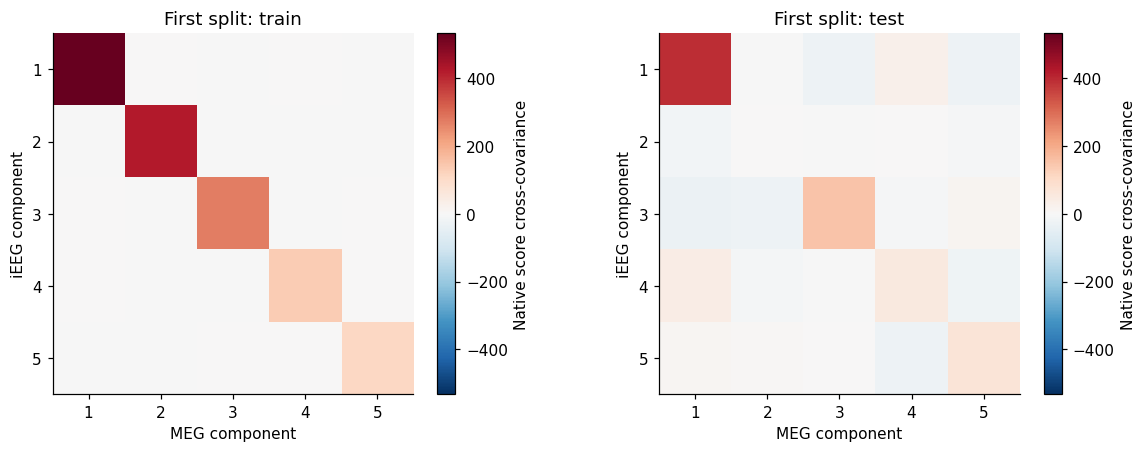

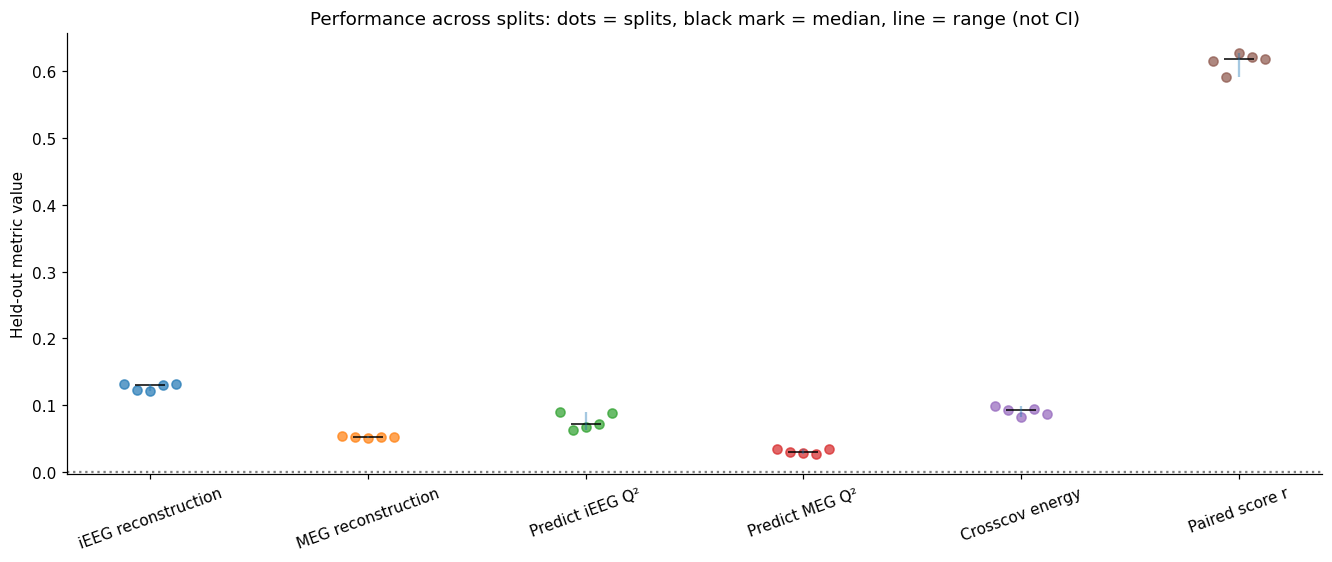

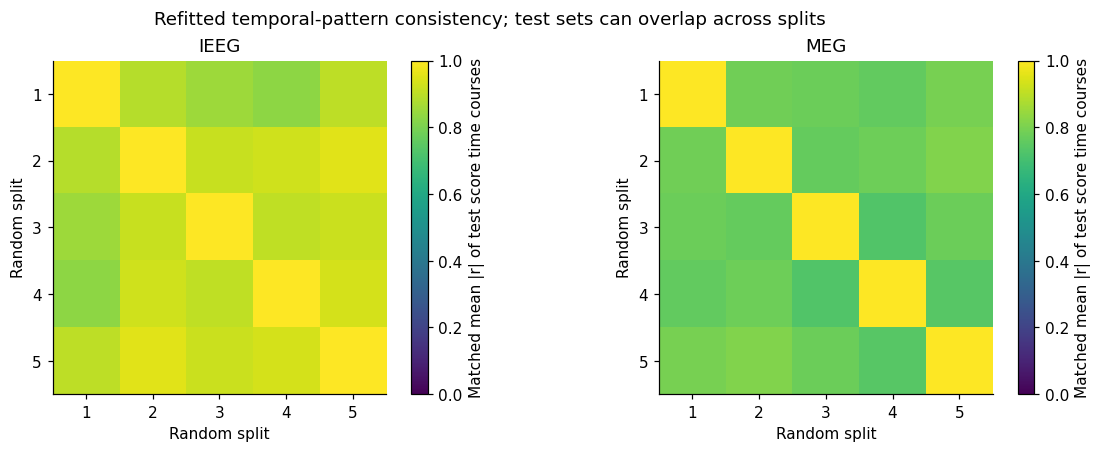

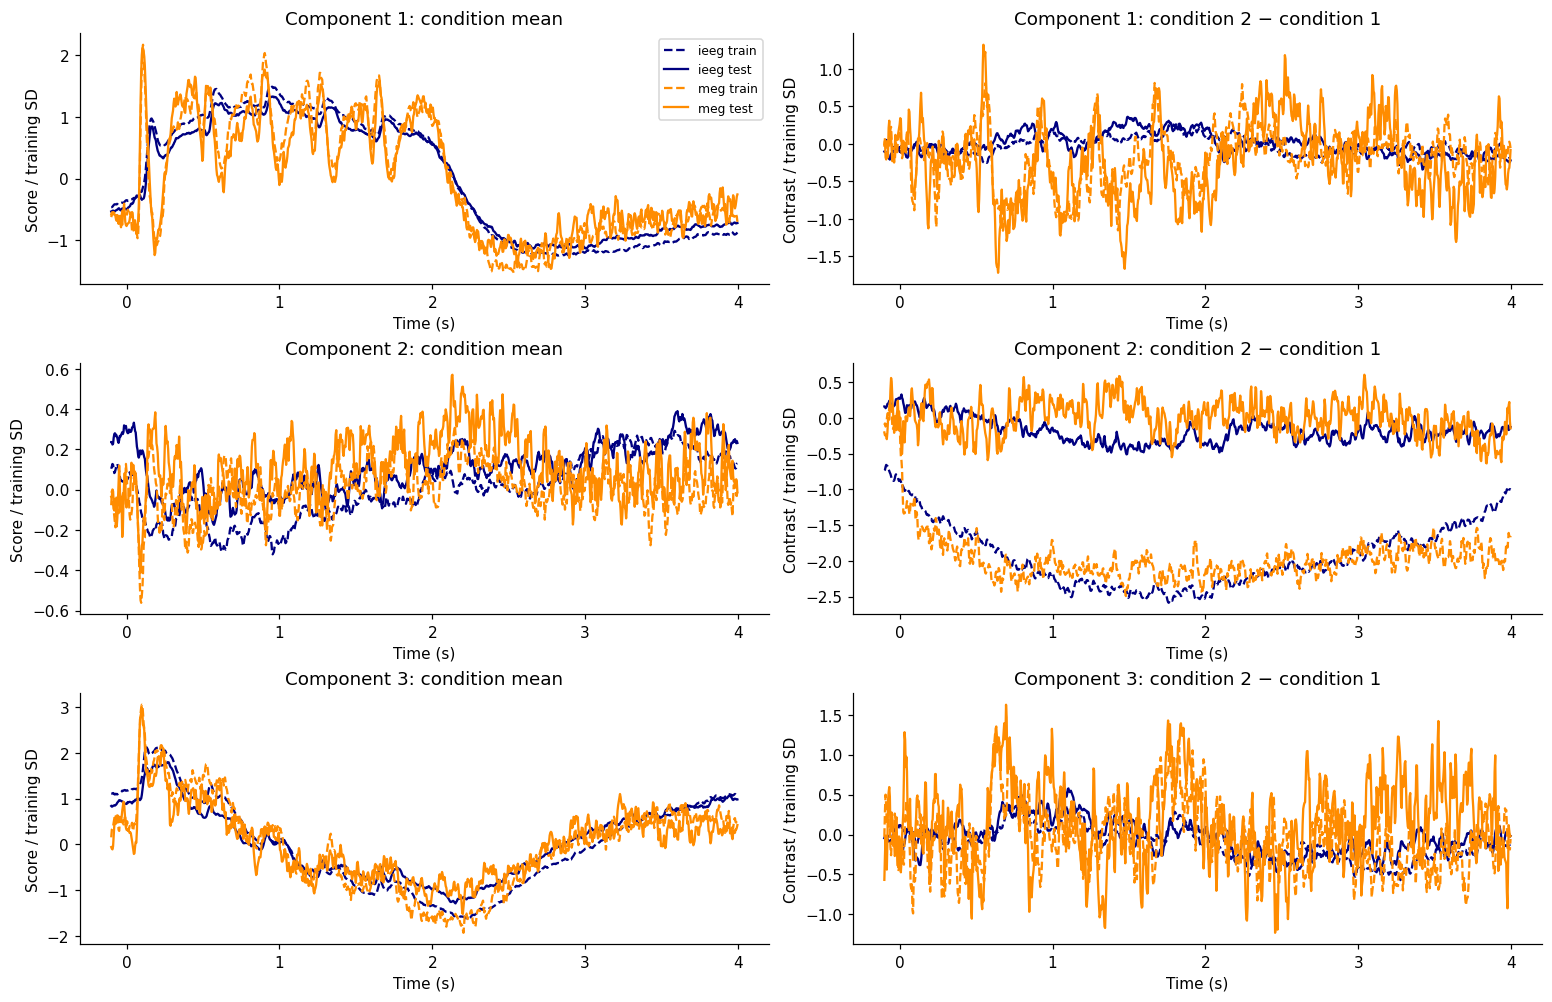

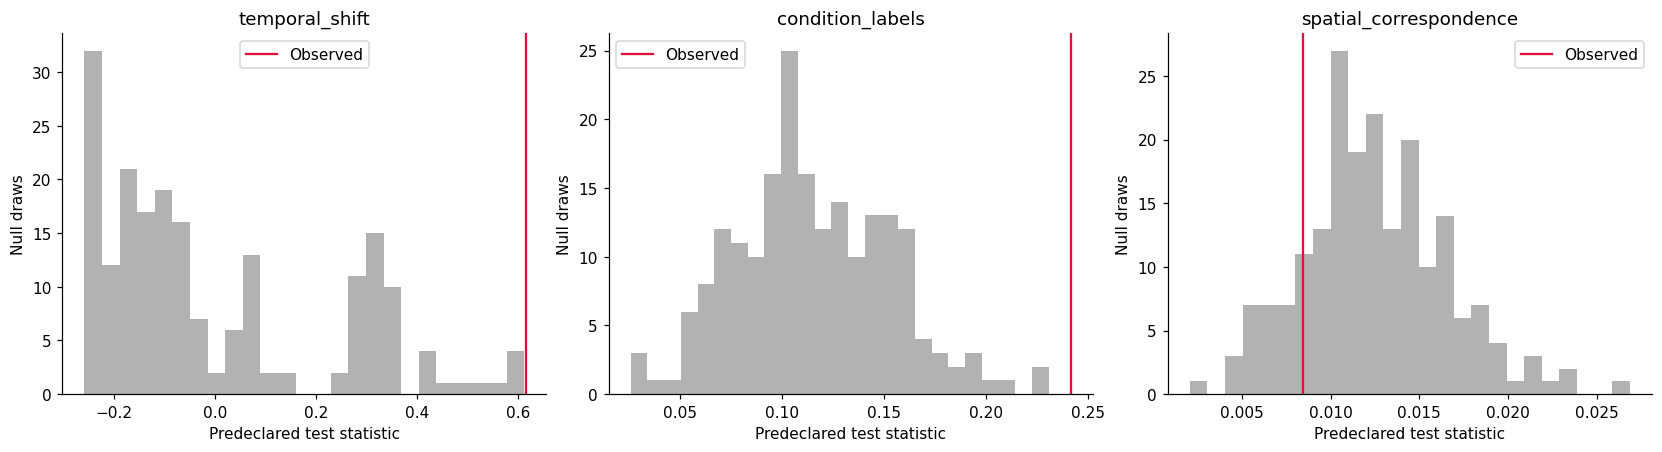

In [14]:
#display(result['components'].round(3))
plot_plssvd_validation(result)


## Stability across random splits

`metric_summary.csv` reports mean, SD, median and range of each train/test metric. The performance-consistency plot shows every test split. These ranges are descriptive, not population confidence intervals.

`fold_stability.csv` compares the refitted score time courses between every pair of splits, separately in iEEG and MEG. It uses mean absolute Pearson correlation with one-to-one component matching, handling sign flips and changes in order. `fold_component_pairs.csv` records the assignments. This post-hoc matching describes stability only and never changes test prediction or cross-covariance metrics. Components may rotate across nearly degenerate solutions; simple matching is not rotation invariant.

In [7]:
# Descriptive consistency across independently refitted, overlapping splits.
display(result['fold_stability'].query("partition == 'test'").round(3))
display(result['metric_summary'].query("partition == 'test'").round(3))

,fold_a,fold_b,partition,modality,n_components,matched_abs_r,status
2,0,1,test,ieeg,5,0.889,ok
3,0,1,test,meg,5,0.785,ok
6,0,2,test,ieeg,5,0.853,ok
7,0,2,test,meg,5,0.774,ok
10,0,3,test,ieeg,5,0.830,ok
11,0,3,test,meg,5,0.762,ok
14,0,4,test,ieeg,5,0.898,ok
15,0,4,test,meg,5,0.795,ok
18,1,2,test,ieeg,5,0.916,ok
19,1,2,test,meg,5,0.765,ok


,partition,metric,count,mean,std,median,min,max
1,test,ieeg_reconstruction_fraction,5,0.127,0.005,0.130,0.122,0.131
3,test,predict_ieeg_q2,5,0.077,0.012,0.072,0.063,0.091
5,test,meg_reconstruction_fraction,5,0.052,0.001,0.052,0.051,0.054
7,test,predict_meg_q2,5,0.031,0.004,0.031,0.026,0.035
9,test,crosscov_energy_fraction,5,0.091,0.006,0.093,0.083,0.098
11,test,paired_crosscov_energy_fraction,5,0.086,0.005,0.086,0.080,0.095
13,test,mean_paired_covariance,5,124.805,6.130,123.483,116.937,133.309
15,test,total_crosscov_energy,5,1940702.350,90584.572,1955235.654,1833445.200,2049179.102
17,test,captured_crosscov_energy,5,177049.933,16004.093,178657.992,151898.656,191872.953
19,test,mean_r,5,0.615,0.014,0.619,0.592,0.627


## Null models: distinct questions
Nulls are evaluated only for the primary fit, keeping preprocessing, fixed component count, and weights fixed. Statistics aggregate the selected components; no test-driven sign flips or component matching are applied.

1. **Temporal shift:** shifts all MEG test scores by the same circular offset within each condition. Tests sensitivity to temporal alignment while preserving circular temporal structure. Epoch-locked responses are nonstationary, so this tail fraction is a **surrogate diagnostic**, not automatically a valid permutation p-value.
2. **Condition labels:** permutes MEG held-out trial labels within participant and exchangeability blocks, preserving counts, then reconstructs projected condition contrasts using the same aggregation. A plus-one permutation tail is interpretable conditionally on exchangeable labels. Blocks containing only one condition cannot be shuffled. Acoustic confounding is not removed by simply labelling this a memory test.
3. **Channel correspondence:** permutes held-out MEG forward-pattern rows within iEEG participant and region (when available). Tests the specified spatial correspondence conditional on the fitted axes. Spatial autocorrelation can violate row exchangeability: treat this as a diagnostic unless those assumptions are justified.

Do not pool tail fractions across overlapping random splits. Report all planned tests and account for multiple inferential claims. The mean tone scaffold cancels in the condition difference only to the extent that it is shared across conditions. A recognition-memory claim still requires known condition semantics and adequate control of acoustic/sequence differences.

In [8]:
display(result['null_tests'])
print(f'Results folder: {OUTPUT_DIR}')

,test,observed,tail_fraction,n_null,interpretation,note
0,temporal_shift,0.615040,0.005,199,surrogate / correspondence diagnostic,NaN
1,condition_labels,0.241367,0.005,199,held-out conditional label permutation,NaN
2,spatial_correspondence,0.008448,0.850,199,surrogate / correspondence diagnostic,NaN


Results folder: /users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/plssvd_eval_full_concatenated
